`conda activate r_env_standr`

In [1]:
library(reshape2)
library(Seurat)
library(ggplot2)
library(dplyr)
library(scales)
library(corrplot)
library(dittoSeq)
library(SCpubr)
library(ggrepel)
library(tidyverse)
library(RColorBrewer)
library(reticulate)
source("scripts/custom_magma.R")
source("scripts/robust_nmf_programs.R")   

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.92 loaded





── SCpubr 2.0.0.9000 ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

ℹ Have a look at extensive tutorials in SCpubr's book.

✔ If you use SCpubr in your research, please cite it accordingly.

★ If the package is useful to you, consider leaving a Star in the GitHub repository.

! Keep track of the package updates on Twitter (@Enblacar) or in the Official NEWS website.

♥ Happy plotting!



── Package version ──

CRAN:           2.0.2
Installed: 2.0.0.9000

⚠ There is a new version available onCRAN!




In [2]:
myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/data/myeloid_rna.rds')
myeloid

An object of class Seurat 
19248 features across 60672 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [3]:
myeloid$Material <- recode(myeloid$Batch_for_correction,
                          '10Xv1_nuclei_multiome' = 'nuclei',
                           '10Xv3_cell_rna'='cell',
                           '10Xv3_nuclei_rna'='nuclei',
                           '10Xv3.1_nuclei_rna'='nuclei')

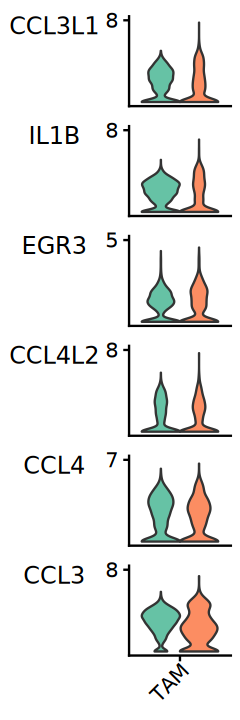

In [25]:
myeloid$TAM <- 'TAM'
scCustomize::Stacked_VlnPlot(seurat_object = subset(myeloid, MP_Assignment=='MP7'), 
                             group.by = 'TAM',
                             features = rev(c('CCL3', 'CCL4', 'CCL4L2','EGR3','IL1B', 'CCL3L1')), 
                             x_lab_rotate = TRUE,
                             colors_use = rev(c('#fc8d62','#66c2a5')), 
                             split.by = "Material")

In [27]:
ggsave('figures/expression_MP7_genes_cell_vs_nuclei.pdf', width = 2)

Saving 2 x 6.67 in image


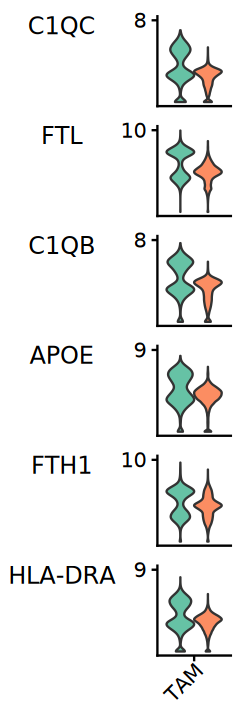

In [28]:
myeloid$TAM <- 'TAM'
scCustomize::Stacked_VlnPlot(seurat_object = subset(myeloid, MP_Assignment=='MP2'), 
                             group.by = 'TAM',
                             features = c('C1QC','FTL','C1QB', 'APOE','FTH1','HLA-DRA'),  
                             x_lab_rotate = TRUE,
                             colors_use = rev(c('#fc8d62','#66c2a5')), 
                             split.by = "Material")

In [32]:
ggsave('figures/expression_MP2_genes_cell_vs_nuclei.pdf', width = 2.3)

Saving 2.3 x 6.67 in image


In [4]:
Idents(myeloid) <- myeloid$Material

differential.expression.results <- FindMarkers(myeloid, ident.1 = "cell", ident.2 = "nuclei", logfc.threshold = log(2))
differential.expression.results

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RPS13,0,5.570755,0.852,0.209,0
RPL39,0,5.852765,0.875,0.234,0
RPS23,0,5.812843,0.880,0.251,0
RPL29,0,5.673454,0.843,0.217,0
RPL30,0,5.743083,0.859,0.233,0
RPL12,0,5.757330,0.849,0.224,0
RPS3A,0,5.973728,0.876,0.256,0
RPL32,0,5.760324,0.872,0.256,0
RPS12,0,5.602495,0.875,0.267,0


In [5]:

significant.genes <- differential.expression.results[differential.expression.results$p_val_adj < 0.05, ]
genes.higher.in.cell <- rownames(significant.genes[significant.genes$avg_log2FC > log(2), ])
genes.higher.in.nuclei <- rownames(significant.genes[significant.genes$avg_log2FC < -log(2), ])

In [6]:
mean.expression <- AggregateExpression(myeloid)

In [7]:

plot.data <- data.frame(
  Gene = rownames(mean.expression$RNA),
  MeanExpressionCell = log1p(mean.expression$RNA[,"cell"]),
  MeanExpressionNuclei = log1p(mean.expression$RNA[,"nuclei"])
)
plot.data$Significance <- ifelse(plot.data$Gene %in% genes.higher.in.cell, "Higher in Cell",
                                 ifelse(plot.data$Gene %in% genes.higher.in.nuclei, "Higher in Nuclei", "Not Significant"))

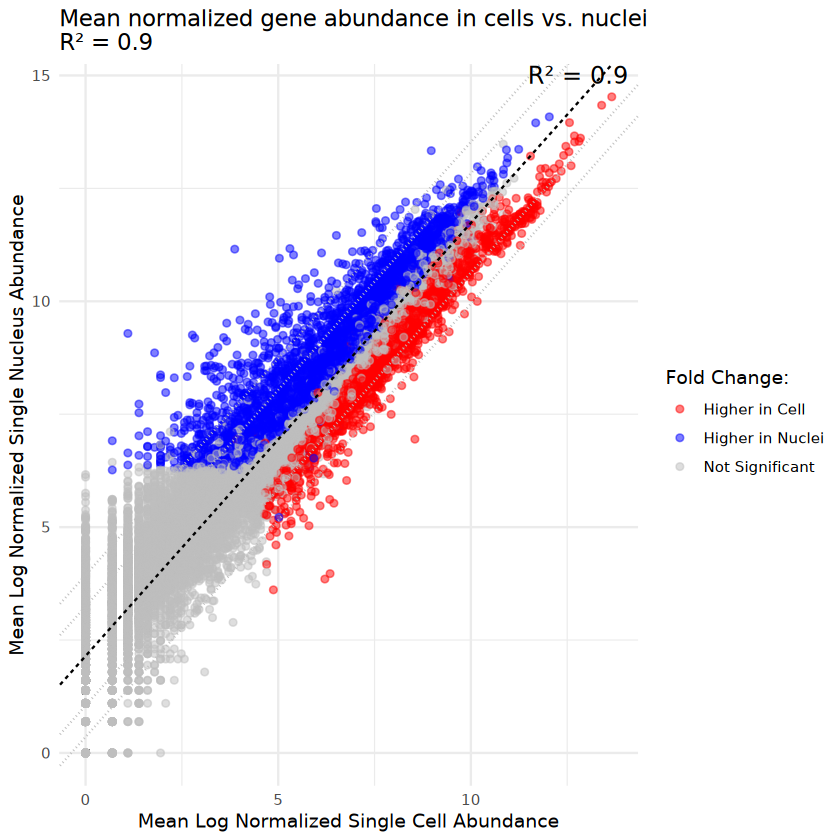

In [8]:

cor.test.result <- cor.test(plot.data$MeanExpressionCell, plot.data$MeanExpressionNuclei)


r_squared <- cor.test.result$estimate^2

# Calculate linear model
lm_fit <- lm(MeanExpressionNuclei ~ MeanExpressionCell, data = plot.data)

regression_line <- ggplot2::geom_abline(intercept = lm_fit$coefficients[1], slope = lm_fit$coefficients[2], color = "black", linetype = "dashed")

two_fold_line_above <- ggplot2::geom_abline(intercept = lm_fit$coefficients[1] + log(3), slope = lm_fit$coefficients[2], color = "grey", linetype = "dotted")
two_fold_line_below <- ggplot2::geom_abline(intercept = lm_fit$coefficients[1] - log(3), slope = lm_fit$coefficients[2], color = "grey", linetype = "dotted")
four_fold_line_above <- ggplot2::geom_abline(intercept = lm_fit$coefficients[1] + log(6), slope = lm_fit$coefficients[2], color = "grey", linetype = "dotted")
four_fold_line_below <- ggplot2::geom_abline(intercept = lm_fit$coefficients[1] - log(6), slope = lm_fit$coefficients[2], color = "grey", linetype = "dotted")

ggplot(plot.data, aes(x = MeanExpressionCell, y = MeanExpressionNuclei, color = Significance)) +
  geom_point(alpha = 0.5) +
  scale_color_manual(values = c("Not Significant" = "grey", "Higher in Cell" = "red", "Higher in Nuclei" = "blue")) +
  regression_line +
  two_fold_line_above +
  two_fold_line_below +
  four_fold_line_above +
  four_fold_line_below +
  scale_x_continuous(limits = c(0, max(plot.data$MeanExpressionCell))) +
  scale_y_continuous(limits = c(0, max(plot.data$MeanExpressionNuclei))) +
  theme_minimal() +
  labs(title = paste("Mean normalized gene abundance in cells vs. nuclei\nR² =", round(r_squared, 2)),
       x = "Mean Log Normalized Single Cell Abundance",
       y = "Mean Log Normalized Single Nucleus Abundance",
       color = "Fold Change:") +
  annotate("text", x = Inf, y = Inf, label = paste("R² =", round(r_squared, 2)),
           hjust = 1.1, vjust = 1.1, size = 5, color = "black")


Warning message:
“ggrepel: 18 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


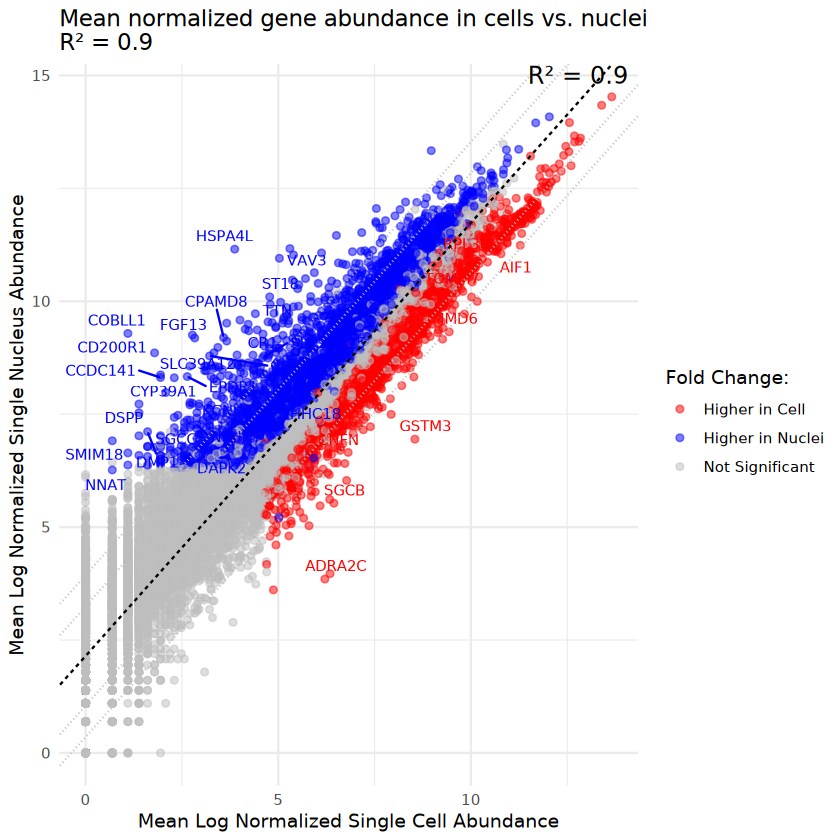

In [9]:
top_genes.higher.in.cell <- head(genes.higher.in.cell[order(-significant.genes[genes.higher.in.cell, "avg_log2FC"])], 25)
top_genes.higher.in.nuclei <- head(genes.higher.in.nuclei[order(significant.genes[genes.higher.in.nuclei, "avg_log2FC"])], 25)


plot.data.labels.higher <- plot.data %>% 
  filter(Gene %in% top_genes.higher.in.cell) %>% 
  arrange(desc(MeanExpressionNuclei))

plot.data.labels.lower <- plot.data %>% 
  filter(Gene %in% top_genes.higher.in.nuclei) %>% 
  arrange(desc(MeanExpressionCell))


ggplot(plot.data, aes(x = MeanExpressionCell, y = MeanExpressionNuclei, color = Significance)) +
  geom_point(alpha = 0.5) +
  geom_text_repel(data = plot.data.labels.higher, aes(label = Gene), size = 3, color = "red") +
  geom_text_repel(data = plot.data.labels.lower, aes(label = Gene), size = 3, color = "blue") +
  scale_color_manual(values = c("Not Significant" = "grey", "Higher in Cell" = "red", "Higher in Nuclei" = "blue")) +
  regression_line +
  two_fold_line_above +
  two_fold_line_below +
  four_fold_line_above +
  four_fold_line_below +
  scale_x_continuous(limits = c(0, max(plot.data$MeanExpressionCell))) +
  scale_y_continuous(limits = c(0, max(plot.data$MeanExpressionNuclei))) +
  theme_minimal() +
  labs(title = paste("Mean normalized gene abundance in cells vs. nuclei\nR² =", round(r_squared, 2)),
       x = "Mean Log Normalized Single Cell Abundance",
       y = "Mean Log Normalized Single Nucleus Abundance",
       color = "Fold Change:") +
  annotate("text", x = Inf, y = Inf, label = paste("R² =", round(r_squared, 2)),
           hjust = 1.1, vjust = 1.1, size = 5, color = "black")

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


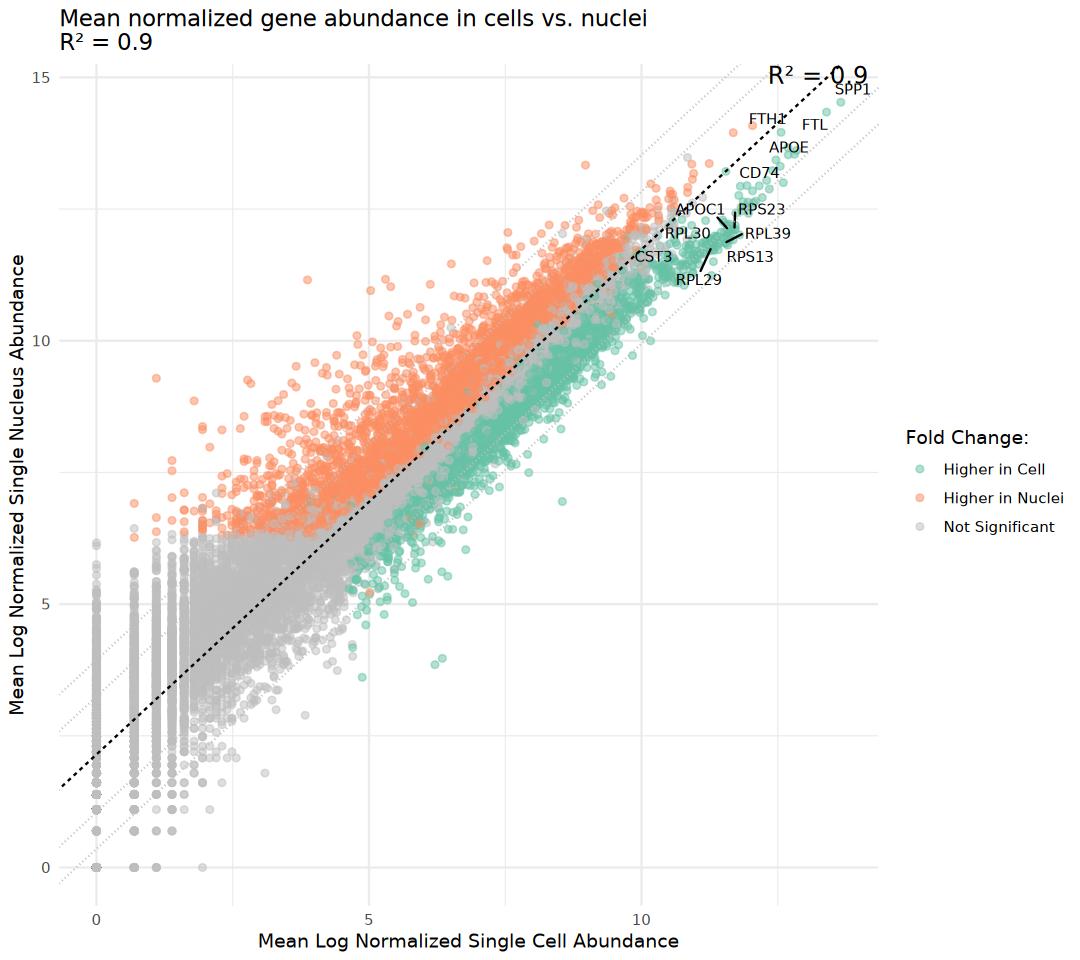

In [10]:
cell_rich_genes <- c("SPP1", "CD74", "FTL", "APOE",
                                    "FTH1", "CST3", "RPL29", "APOC1",
                    'RPS13','RPL39','RPS23','RPL29','RPL30')

plot.data.interest <- plot.data %>% 
  filter(Gene %in% cell_rich_genes)


top_genes.higher.in.cell <- head(genes.higher.in.cell[order(-significant.genes[genes.higher.in.cell, "avg_log2FC"])], 25)
top_genes.higher.in.nuclei <- head(genes.higher.in.nuclei[order(significant.genes[genes.higher.in.nuclei, "avg_log2FC"])], 25)


plot.data.labels.higher <- plot.data %>% 
  filter(Gene %in% top_genes.higher.in.cell) %>% 
  arrange(desc(MeanExpressionNuclei))

plot.data.labels.lower <- plot.data %>% 
  filter(Gene %in% top_genes.higher.in.nuclei) %>% 
  arrange(desc(MeanExpressionCell))

options(repr.plot.height = 8, repr.plot.width = 9)

ggplot(plot.data, aes(x = MeanExpressionCell, y = MeanExpressionNuclei, color = Significance)) +
  geom_point(alpha = 0.5) +
  geom_text_repel(data = plot.data.interest, aes(label = Gene), 
                  size = 3, color = "black",  alpha = 1) +
  scale_color_manual(values = c("Not Significant" = "grey", "Higher in Cell" = "#66c2a5", "Higher in Nuclei" = "#fc8d62")) +
  regression_line +
  two_fold_line_above +
  two_fold_line_below +
  four_fold_line_above +
  four_fold_line_below +
  scale_x_continuous(limits = c(0, max(plot.data$MeanExpressionCell))) +
  scale_y_continuous(limits = c(0, max(plot.data$MeanExpressionNuclei))) +
  theme_minimal() +
  labs(title = paste("Mean normalized gene abundance in cells vs. nuclei\nR² =", round(r_squared, 2)),
       x = "Mean Log Normalized Single Cell Abundance",
       y = "Mean Log Normalized Single Nucleus Abundance",
       color = "Fold Change:") +
  annotate("text", x = Inf, y = Inf, label = paste("R² =", round(r_squared, 2)),
           hjust = 1.1, vjust = 1.1, size = 5, color = "black")

In [18]:
ggsave('figures/scatter_plot_gene_abundance_cell_vs_nuclei.pdf', width = 7.5)

Saving 7.5 x 6.67 in image
Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


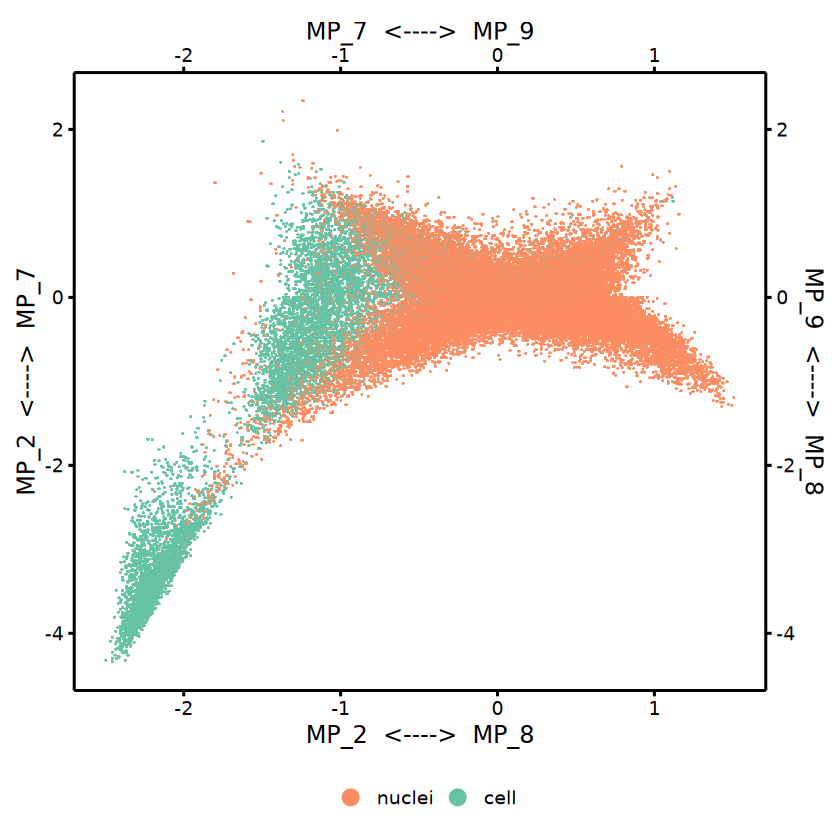

In [62]:
myeloid$Material <- factor(myeloid$Material,
                          levels=c('nuclei','cell'))

do_CellularStatesPlot(sample = subset(myeloid,leiden_1_3 %in% c('8','10','13'), 
                                      invert=TRUE),
                      colors.use = cluster_cols,
                      group.by = 'Material',
                      pt.size = 3,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

In [9]:
cluster_cols <- c("nuclei" = "#fc8d62",
                 "cell"= '#66c2a5')

In [14]:
myeloid$Material <- recode(myeloid$Batch_for_correction,
                          '10Xv1_nuclei_multiome' = 'nuclei',
                           '10Xv3_cell_rna'='cell',
                           '10Xv3_nuclei_rna'='nuclei',
                           '10Xv3.1_nuclei_rna'='nuclei')

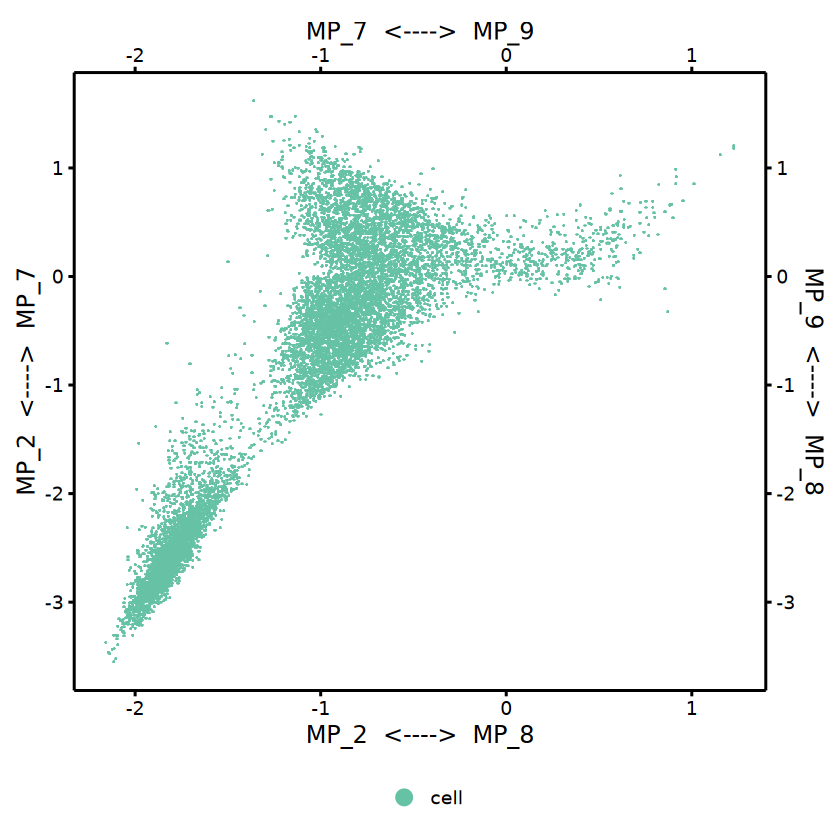

In [15]:
do_CellularStatesPlot(sample = subset(myeloid, Material == 'cell'),
                      colors.use = cluster_cols,
                      group.by = 'Material',
                      pt.size = 3,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

In [16]:
ggsave('figures/states_plot_cell_only.pdf')

Saving 6.67 x 6.67 in image


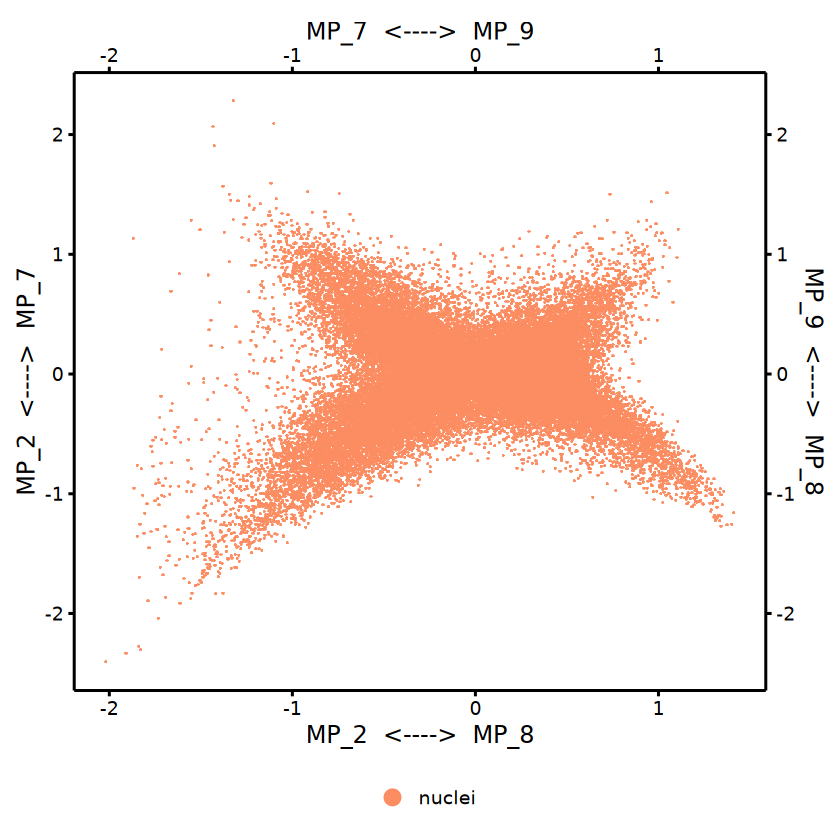

In [17]:
do_CellularStatesPlot(sample = subset(myeloid, Material == 'cell' | leiden_1_3 %in% c('8','10','7','13'), 
                                      invert=TRUE),
                      colors.use = cluster_cols,
                      group.by = 'Material',
                      pt.size = 3,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE)

In [18]:
ggsave('figures/states_plot_nuclei_only.pdf')

Saving 6.67 x 6.67 in image
